# MLP Training and Experiments for MAGIC Telescope

Training and evaluating neural network models on the MAGIC Gamma Telescope dataset using our custom numpy-based framework.

## Research objective

The objective of this project is to classify MAGIC Gamma Telescope events into gamma (signal) and hadron (background) classes using a multilayer perceptron (MLP).
The study focuses on supervised binary classification with standardized input features and reproducible training conditions.
Beyond building a baseline model, the project evaluates how architecture depth, optimizer choice, learning rate, and dropout regularization influence model performance.
The goal is both predictive performance and a transparent understanding of which design choices contribute to better results.

## 1. Setup and Data Loading

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

project_root = Path.cwd()
if not (project_root / "src").exists() and (project_root.parent / "src").exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.preprocessing import load_magic_dataset, preprocess_data
from src.utils import set_seed, print_model_summary
from src.experiments import run_single_experiment

set_seed(42)
X, y = load_magic_dataset()
data = preprocess_data(X, y)

print(f"Dataset shape: X={X.shape}, y={y.shape}")
print(f"Class distribution: {np.bincount(y.astype(int))}")
print(f"Train: {data['train']['X'].shape}, Val: {data['val']['X'].shape}, Test: {data['test']['X'].shape}")

Loading MAGIC Gamma Telescope dataset from UCI ML Repository...
✓ Dataset loaded: 19020 samples, 10 features
Removed 115 duplicate rows before splitting.
Dataset shape: X=(19020, 10), y=(19020,)
Class distribution: [ 6688 12332]
Train: (11343, 10), Val: (3781, 10), Test: (3781, 10)


## 2. Baseline Model Definition

In [2]:
from src.model import Model
from src.layers import Linear
from src.activations import ReLU, Sigmoid
from src.losses import BCELoss
from src.optimizers import Adam

model = Model()
model.add_module(Linear(10, 32), 'linear1')
model.add_module(ReLU(), 'relu1')
model.add_module(Linear(32, 16), 'linear2')
model.add_module(ReLU(), 'relu2')
model.add_module(Linear(16, 1), 'linear3')
model.add_module(Sigmoid(), 'sigmoid')

print_model_summary(model)


Model Architecture
linear1                        | Linear
                               | Params: 352 (W: (32, 10), b: (32, 1))
relu1                          | ReLU
linear2                        | Linear
                               | Params: 528 (W: (16, 32), b: (16, 1))
relu2                          | ReLU
linear3                        | Linear
                               | Params: 17 (W: (1, 16), b: (1, 1))
sigmoid                        | Sigmoid
Total trainable parameters: 897



## 3. Baseline Training

Epoch 1/100 - loss: 0.4407 - val_loss: 0.3757 - acc: 0.8369 - val_acc: 0.8392
Epoch 10/100 - loss: 0.3140 - val_loss: 0.3300 - acc: 0.8716 - val_acc: 0.8625
Epoch 20/100 - loss: 0.2986 - val_loss: 0.3239 - acc: 0.8795 - val_acc: 0.8646
Epoch 30/100 - loss: 0.2909 - val_loss: 0.3230 - acc: 0.8828 - val_acc: 0.8680
Epoch 40/100 - loss: 0.2853 - val_loss: 0.3215 - acc: 0.8843 - val_acc: 0.8709
Epoch 50/100 - loss: 0.2821 - val_loss: 0.3201 - acc: 0.8838 - val_acc: 0.8670
Early stopping at epoch 52
Restored best model weights from lowest validation loss.
Baseline training complete.


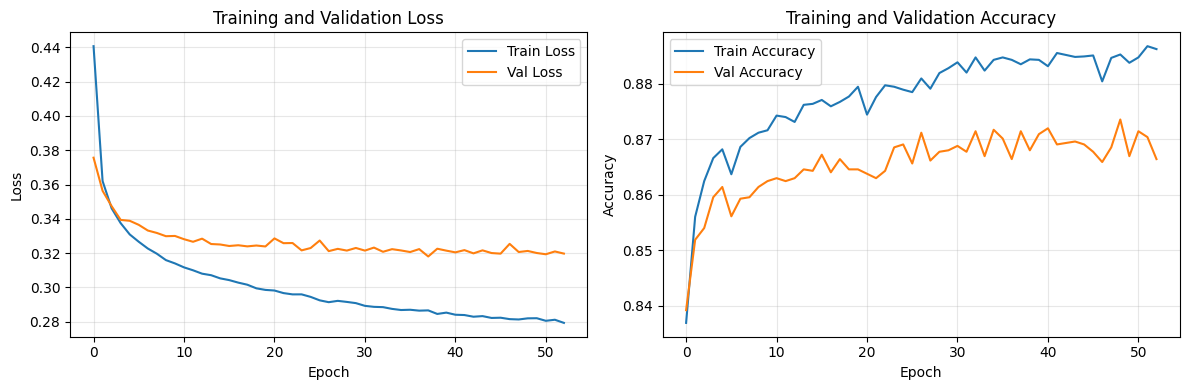

In [3]:
from src.trainer import Trainer
from src.visualization import plot_training_history

loss_fn = BCELoss()
optimizer = Adam(lr=0.001)
trainer = Trainer(model, loss_fn, optimizer, batch_size=32)

history = trainer.fit(
    data['train']['X'], data['train']['y'],
    data['val']['X'], data['val']['y'],
    epochs=100,
    early_stopping=True,
    patience=15
)

plot_training_history(history)
print('Baseline training complete.')

## 4. Baseline Evaluation (Metrics + Plots)

Test Set Metrics:
accuracy       : 0.8794
precision      : 0.8792
recall         : 0.9448
f1             : 0.9109


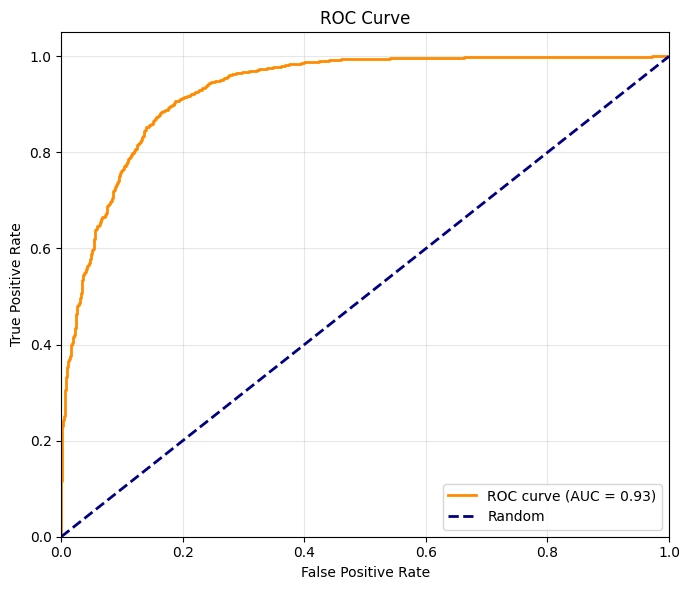

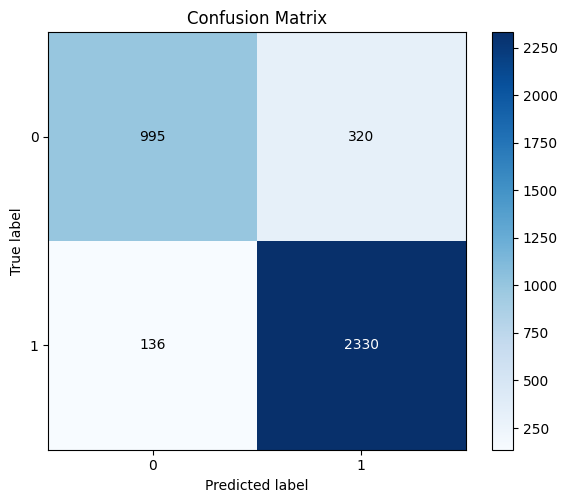

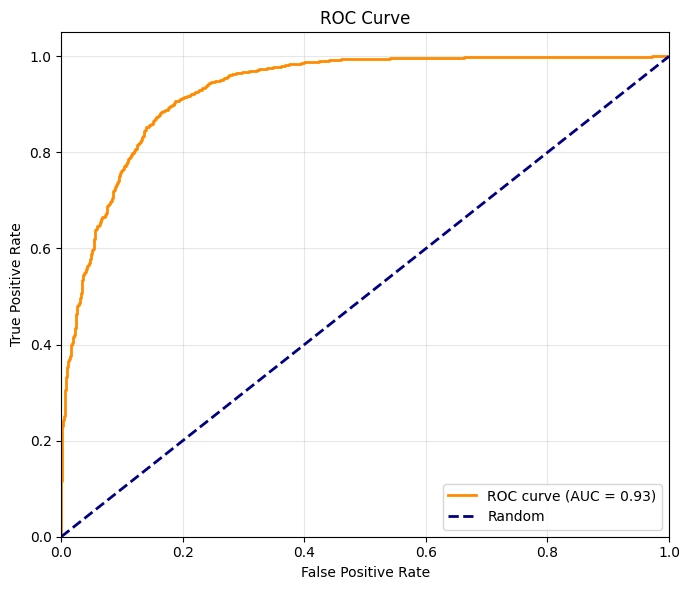

In [4]:
from src.visualization import plot_confusion_matrix, plot_roc_curve

_, test_metrics = trainer.evaluate(data['test']['X'], data['test']['y'])
print('Test Set Metrics:')
print('=' * 40)
for metric, value in test_metrics.items():
    print(f"{metric:15s}: {value:.4f}")
print('=' * 40)

y_test = data['test']['y']
y_proba = trainer.predict_proba(data['test']['X'])
y_pred = trainer.predict(data['test']['X'])

plot_confusion_matrix(y_test, y_pred)
plot_roc_curve(y_test, y_proba)

## 5. Experiment Design and Execution

Experiments are defined and executed directly in the notebook for transparency.
Each run changes one design choice (depth, activation, optimizer, learning rate, dropout), while keeping the same data split and seed.
All configurations use hidden_layers and are executed via run_single_experiment.

In [5]:
experiment_results = []

def run_and_show(config):
    print(f"Running: {config['name']}")
    result = run_single_experiment(data, config, seed=42)
    experiment_results.append(result)
    display(pd.DataFrame([result]).round(4))

### Experiment 1: baseline_relu_adam

Baseline model with two hidden layers, ReLU activation, and Adam optimizer.

In [6]:
config = {
    'name': 'baseline_relu_adam',
    'hidden_layers': [32, 16],
    'activation': 'relu',
    'optimizer': 'adam',
    'learning_rate': 1e-3,
    'batch_size': 32,
    'epochs': 80,
    'dropout': 0.0,
}
run_and_show(config)

Running: baseline_relu_adam
Epoch 1/80 - loss: 0.4407 - val_loss: 0.3757 - acc: 0.8369 - val_acc: 0.8392
Epoch 10/80 - loss: 0.3140 - val_loss: 0.3300 - acc: 0.8716 - val_acc: 0.8625
Epoch 20/80 - loss: 0.2986 - val_loss: 0.3239 - acc: 0.8795 - val_acc: 0.8646
Epoch 30/80 - loss: 0.2909 - val_loss: 0.3230 - acc: 0.8828 - val_acc: 0.8680
Epoch 40/80 - loss: 0.2853 - val_loss: 0.3215 - acc: 0.8843 - val_acc: 0.8709
Epoch 50/80 - loss: 0.2821 - val_loss: 0.3201 - acc: 0.8838 - val_acc: 0.8670
Early stopping at epoch 52
Restored best model weights from lowest validation loss.


,experiment_name,architecture,activation,optimizer,learning_rate,batch_size,epochs,dropout,best_validation_loss,validation_accuracy,validation_f1,test_accuracy,test_precision,test_recall,test_f1
0,baseline_relu_adam,"[32, 16]",relu,adam,0.001,32,80,0.0,0.3181,0.8715,0.9058,0.8794,0.8792,0.9448,0.9109


### Experiment 2: deeper_relu_adam

Deeper ReLU network to test whether added depth improves validation metrics.

In [7]:
config = {
    'name': 'deeper_relu_adam',
    'hidden_layers': [64, 32, 16],
    'activation': 'relu',
    'optimizer': 'adam',
    'learning_rate': 1e-3,
    'batch_size': 32,
    'epochs': 100,
    'dropout': 0.0,
}
run_and_show(config)

Running: deeper_relu_adam
Epoch 1/100 - loss: 0.4275 - val_loss: 0.3664 - acc: 0.8500 - val_acc: 0.8434
Epoch 10/100 - loss: 0.3009 - val_loss: 0.3265 - acc: 0.8761 - val_acc: 0.8635
Epoch 20/100 - loss: 0.2780 - val_loss: 0.3246 - acc: 0.8842 - val_acc: 0.8646
Early stopping at epoch 27
Restored best model weights from lowest validation loss.


,experiment_name,architecture,activation,optimizer,learning_rate,batch_size,epochs,dropout,best_validation_loss,validation_accuracy,validation_f1,test_accuracy,test_precision,test_recall,test_f1
0,deeper_relu_adam,"[64, 32, 16]",relu,adam,0.001,32,100,0.0,0.3188,0.8672,0.9016,0.8749,0.8834,0.9311,0.9066


### Experiment 3: tanh_sgd

Alternative activation (Tanh) with SGD optimizer.

In [8]:
config = {
    'name': 'tanh_sgd',
    'hidden_layers': [32, 16],
    'activation': 'tanh',
    'optimizer': 'sgd',
    'learning_rate': 1e-2,
    'batch_size': 32,
    'epochs': 100,
    'dropout': 0.0,
}
run_and_show(config)

Running: tanh_sgd
Epoch 1/100 - loss: 0.5204 - val_loss: 0.4753 - acc: 0.7880 - val_acc: 0.7826
Epoch 10/100 - loss: 0.3965 - val_loss: 0.4015 - acc: 0.8311 - val_acc: 0.8313
Epoch 20/100 - loss: 0.3598 - val_loss: 0.3698 - acc: 0.8520 - val_acc: 0.8482
Epoch 30/100 - loss: 0.3438 - val_loss: 0.3547 - acc: 0.8580 - val_acc: 0.8529
Epoch 40/100 - loss: 0.3334 - val_loss: 0.3446 - acc: 0.8642 - val_acc: 0.8577
Epoch 50/100 - loss: 0.3265 - val_loss: 0.3402 - acc: 0.8626 - val_acc: 0.8598
Epoch 60/100 - loss: 0.3206 - val_loss: 0.3352 - acc: 0.8690 - val_acc: 0.8627
Epoch 70/100 - loss: 0.3165 - val_loss: 0.3335 - acc: 0.8682 - val_acc: 0.8649
Epoch 80/100 - loss: 0.3128 - val_loss: 0.3344 - acc: 0.8690 - val_acc: 0.8627
Epoch 90/100 - loss: 0.3097 - val_loss: 0.3287 - acc: 0.8711 - val_acc: 0.8670
Epoch 100/100 - loss: 0.3064 - val_loss: 0.3276 - acc: 0.8734 - val_acc: 0.8680


,experiment_name,architecture,activation,optimizer,learning_rate,batch_size,epochs,dropout,best_validation_loss,validation_accuracy,validation_f1,test_accuracy,test_precision,test_recall,test_f1
0,tanh_sgd,"[32, 16]",tanh,sgd,0.01,32,100,0.0,0.3269,0.8659,0.9016,0.8723,0.8766,0.9359,0.9053


### Experiment 4: relu_rmsprop

ReLU architecture with RMSprop optimizer to compare optimization behavior.

In [9]:
config = {
    'name': 'relu_rmsprop',
    'hidden_layers': [32, 16],
    'activation': 'relu',
    'optimizer': 'rmsprop',
    'learning_rate': 1e-3,
    'batch_size': 32,
    'epochs': 100,
    'dropout': 0.0,
}
run_and_show(config)

Running: relu_rmsprop
Epoch 1/100 - loss: 0.4360 - val_loss: 0.3822 - acc: 0.8313 - val_acc: 0.8323
Epoch 10/100 - loss: 0.3185 - val_loss: 0.3345 - acc: 0.8693 - val_acc: 0.8596
Epoch 20/100 - loss: 0.3032 - val_loss: 0.3277 - acc: 0.8758 - val_acc: 0.8643
Epoch 30/100 - loss: 0.2971 - val_loss: 0.3261 - acc: 0.8810 - val_acc: 0.8675
Epoch 40/100 - loss: 0.2920 - val_loss: 0.3260 - acc: 0.8809 - val_acc: 0.8699
Early stopping at epoch 49
Restored best model weights from lowest validation loss.


,experiment_name,architecture,activation,optimizer,learning_rate,batch_size,epochs,dropout,best_validation_loss,validation_accuracy,validation_f1,test_accuracy,test_precision,test_recall,test_f1
0,relu_rmsprop,"[32, 16]",relu,rmsprop,0.001,32,100,0.0,0.3224,0.8672,0.9019,0.8733,0.8782,0.9355,0.9059


### Experiment 5: relu_adam_small_lr

Same baseline architecture with smaller Adam learning rate for stability.

In [10]:
config = {
    'name': 'relu_adam_small_lr',
    'hidden_layers': [32, 16],
    'activation': 'relu',
    'optimizer': 'adam',
    'learning_rate': 3e-4,
    'batch_size': 32,
    'epochs': 120,
    'dropout': 0.0,
}
run_and_show(config)

Running: relu_adam_small_lr
Epoch 1/120 - loss: 0.5340 - val_loss: 0.4522 - acc: 0.8047 - val_acc: 0.8003
Epoch 10/120 - loss: 0.3387 - val_loss: 0.3453 - acc: 0.8639 - val_acc: 0.8590
Epoch 20/120 - loss: 0.3218 - val_loss: 0.3348 - acc: 0.8687 - val_acc: 0.8574
Epoch 30/120 - loss: 0.3127 - val_loss: 0.3289 - acc: 0.8717 - val_acc: 0.8606
Epoch 40/120 - loss: 0.3066 - val_loss: 0.3263 - acc: 0.8736 - val_acc: 0.8638
Epoch 50/120 - loss: 0.3024 - val_loss: 0.3246 - acc: 0.8760 - val_acc: 0.8638
Epoch 60/120 - loss: 0.2985 - val_loss: 0.3234 - acc: 0.8775 - val_acc: 0.8670
Epoch 70/120 - loss: 0.2950 - val_loss: 0.3233 - acc: 0.8780 - val_acc: 0.8664
Epoch 80/120 - loss: 0.2924 - val_loss: 0.3217 - acc: 0.8808 - val_acc: 0.8670
Epoch 90/120 - loss: 0.2894 - val_loss: 0.3218 - acc: 0.8806 - val_acc: 0.8659
Epoch 100/120 - loss: 0.2870 - val_loss: 0.3214 - acc: 0.8814 - val_acc: 0.8683
Epoch 110/120 - loss: 0.2854 - val_loss: 0.3222 - acc: 0.8825 - val_acc: 0.8707
Early stopping at epoch

,experiment_name,architecture,activation,optimizer,learning_rate,batch_size,epochs,dropout,best_validation_loss,validation_accuracy,validation_f1,test_accuracy,test_precision,test_recall,test_f1
0,relu_adam_small_lr,"[32, 16]",relu,adam,0.0003,32,120,0.0,0.3211,0.8709,0.9051,0.8781,0.877,0.9457,0.91


### Experiment 6: relu_adam_dropout

Deeper ReLU architecture with dropout regularization (p=0.2).

In [11]:
config = {
    'name': 'relu_adam_dropout',
    'hidden_layers': [64, 32, 16],
    'activation': 'relu',
    'optimizer': 'adam',
    'learning_rate': 1e-3,
    'batch_size': 32,
    'epochs': 120,
    'dropout': 0.2,
}
run_and_show(config)

Running: relu_adam_dropout
Epoch 1/120 - loss: 0.4826 - val_loss: 0.3944 - acc: 0.8305 - val_acc: 0.8273
Epoch 10/120 - loss: 0.3282 - val_loss: 0.3286 - acc: 0.8713 - val_acc: 0.8643
Epoch 20/120 - loss: 0.3188 - val_loss: 0.3174 - acc: 0.8815 - val_acc: 0.8704
Epoch 30/120 - loss: 0.3041 - val_loss: 0.3111 - acc: 0.8842 - val_acc: 0.8717
Epoch 40/120 - loss: 0.3008 - val_loss: 0.3112 - acc: 0.8897 - val_acc: 0.8730
Early stopping at epoch 48
Restored best model weights from lowest validation loss.


,experiment_name,architecture,activation,optimizer,learning_rate,batch_size,epochs,dropout,best_validation_loss,validation_accuracy,validation_f1,test_accuracy,test_precision,test_recall,test_f1
0,relu_adam_dropout,"[64, 32, 16]",relu,adam,0.001,32,120,0.2,0.3082,0.8717,0.9058,0.8781,0.8787,0.9432,0.9098


### Experiment 7: leaky_relu_adam

LeakyReLU variant to test robustness against dead neurons.

In [12]:
config = {
    'name': 'leaky_relu_adam',
    'hidden_layers': [32, 16],
    'activation': 'leaky_relu',
    'optimizer': 'adam',
    'learning_rate': 1e-3,
    'batch_size': 32,
    'epochs': 100,
    'dropout': 0.0,
}
run_and_show(config)

Running: leaky_relu_adam
Epoch 1/100 - loss: 0.4403 - val_loss: 0.3755 - acc: 0.8374 - val_acc: 0.8387
Epoch 10/100 - loss: 0.3148 - val_loss: 0.3308 - acc: 0.8715 - val_acc: 0.8614
Epoch 20/100 - loss: 0.3003 - val_loss: 0.3236 - acc: 0.8768 - val_acc: 0.8625
Epoch 30/100 - loss: 0.2935 - val_loss: 0.3237 - acc: 0.8821 - val_acc: 0.8683
Epoch 40/100 - loss: 0.2879 - val_loss: 0.3225 - acc: 0.8827 - val_acc: 0.8696
Epoch 50/100 - loss: 0.2837 - val_loss: 0.3196 - acc: 0.8845 - val_acc: 0.8691
Early stopping at epoch 52
Restored best model weights from lowest validation loss.


,experiment_name,architecture,activation,optimizer,learning_rate,batch_size,epochs,dropout,best_validation_loss,validation_accuracy,validation_f1,test_accuracy,test_precision,test_recall,test_f1
0,leaky_relu_adam,"[32, 16]",leaky_relu,adam,0.001,32,100,0.0,0.3183,0.8707,0.9051,0.8762,0.8756,0.9444,0.9087


### Experiment 8: relu_sgd_momentum

ReLU baseline with SGD + momentum for optimizer comparison.

In [13]:
config = {
    'name': 'relu_sgd_momentum',
    'hidden_layers': [32, 16],
    'activation': 'relu',
    'optimizer': 'sgd_momentum',
    'learning_rate': 1e-2,
    'batch_size': 32,
    'epochs': 100,
    'dropout': 0.0,
}
run_and_show(config)

Running: relu_sgd_momentum
Epoch 1/100 - loss: 0.5406 - val_loss: 0.4677 - acc: 0.7911 - val_acc: 0.7863
Epoch 10/100 - loss: 0.3550 - val_loss: 0.3568 - acc: 0.8539 - val_acc: 0.8537
Epoch 20/100 - loss: 0.3328 - val_loss: 0.3397 - acc: 0.8637 - val_acc: 0.8604
Epoch 30/100 - loss: 0.3220 - val_loss: 0.3321 - acc: 0.8697 - val_acc: 0.8635
Epoch 40/100 - loss: 0.3154 - val_loss: 0.3295 - acc: 0.8704 - val_acc: 0.8651
Epoch 50/100 - loss: 0.3106 - val_loss: 0.3269 - acc: 0.8735 - val_acc: 0.8635
Epoch 60/100 - loss: 0.3066 - val_loss: 0.3261 - acc: 0.8745 - val_acc: 0.8643
Epoch 70/100 - loss: 0.3028 - val_loss: 0.3248 - acc: 0.8757 - val_acc: 0.8664
Epoch 80/100 - loss: 0.3003 - val_loss: 0.3224 - acc: 0.8762 - val_acc: 0.8693
Epoch 90/100 - loss: 0.2976 - val_loss: 0.3207 - acc: 0.8775 - val_acc: 0.8667
Epoch 100/100 - loss: 0.2953 - val_loss: 0.3189 - acc: 0.8779 - val_acc: 0.8667


,experiment_name,architecture,activation,optimizer,learning_rate,batch_size,epochs,dropout,best_validation_loss,validation_accuracy,validation_f1,test_accuracy,test_precision,test_recall,test_f1
0,relu_sgd_momentum,"[32, 16]",relu,sgd_momentum,0.01,32,100,0.0,0.3189,0.8667,0.9017,0.8752,0.8802,0.9359,0.9072


## 6. Final Experiment Comparison

We aggregate all experiment outputs, rank them by validation F1, save to CSV, and visualize the comparison.

Saved experiment results to: ..\results\experiments.csv


,experiment_name,architecture,activation,optimizer,learning_rate,batch_size,epochs,dropout,best_validation_loss,validation_accuracy,validation_f1,test_accuracy,test_precision,test_recall,test_f1
0,baseline_relu_adam,"[32, 16]",relu,adam,0.0010,32,80,0.0,0.3181,0.8715,0.9058,0.8794,0.8792,0.9448,0.9109
1,relu_adam_dropout,"[64, 32, 16]",relu,adam,0.0010,32,120,0.2,0.3082,0.8717,0.9058,0.8781,0.8787,0.9432,0.9098
2,leaky_relu_adam,"[32, 16]",leaky_relu,adam,0.0010,32,100,0.0,0.3183,0.8707,0.9051,0.8762,0.8756,0.9444,0.9087
3,relu_adam_small_lr,"[32, 16]",relu,adam,0.0003,32,120,0.0,0.3211,0.8709,0.9051,0.8781,0.8770,0.9457,0.9100
4,relu_rmsprop,"[32, 16]",relu,rmsprop,0.0010,32,100,0.0,0.3224,0.8672,0.9019,0.8733,0.8782,0.9355,0.9059
5,relu_sgd_momentum,"[32, 16]",relu,sgd_momentum,0.0100,32,100,0.0,0.3189,0.8667,0.9017,0.8752,0.8802,0.9359,0.9072
6,tanh_sgd,"[32, 16]",tanh,sgd,0.0100,32,100,0.0,0.3269,0.8659,0.9016,0.8723,0.8766,0.9359,0.9053
7,deeper_relu_adam,"[64, 32, 16]",relu,adam,0.0010,32,100,0.0,0.3188,0.8672,0.9016,0.8749,0.8834,0.9311,0.9066


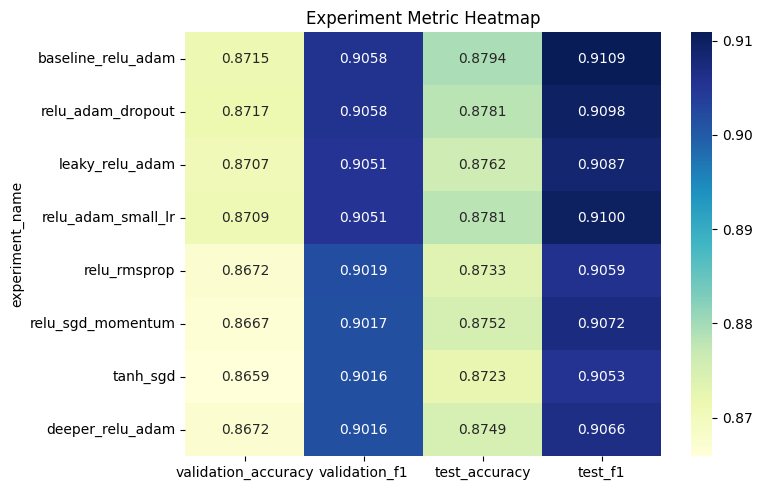

In [16]:
results_df = pd.DataFrame(experiment_results)
results_df = results_df.sort_values('validation_f1', ascending=False).reset_index(drop=True)

results_df_rounded = results_df.copy()
numeric_cols = results_df_rounded.select_dtypes(include=['number']).columns
results_df_rounded[numeric_cols] = results_df_rounded[numeric_cols].round(4)

csv_path = Path('../results/experiments.csv')
csv_path.parent.mkdir(parents=True, exist_ok=True)
results_df.to_csv(csv_path, index=False)

print(f"Saved experiment results to: {csv_path}")
display(results_df_rounded)


metric_cols = ['validation_accuracy', 'validation_f1', 'test_accuracy', 'test_f1']
heatmap_df = results_df_rounded.set_index('experiment_name')[metric_cols]

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_df, annot=True, fmt='.4f', cmap='YlGnBu')
plt.title('Experiment Metric Heatmap')
plt.tight_layout()
plt.show()

## Hypotheses

- H1: A simple MLP with normalized input features can achieve good classification performance on the MAGIC dataset.
- H2: Increasing model depth will improve classification performance.
- H3: Adding dropout will improve generalization and validation performance.
- H4: The choice of optimizer will affect model performance and convergence.

## How the hypotheses will be tested

- H1 will be evaluated using the baseline experiment.
- H2 will be tested by comparing a shallow model against a deeper model under otherwise comparable settings.
- H3 will be tested by comparing the deeper architecture with and without dropout regularization.
- H4 will be tested by comparing optimizers Adam, SGD, RMSprop, and SGD with momentum.

Evaluation will report accuracy, precision, recall, and F1 score for validation and test sets.

## 7. Hypothesis Evaluation

This section evaluates H1-H4 using results_df only, without running new experiments.

,hypothesis,condition,result
0,H1,baseline validation_f1 >= 0.88 and test_f1 >= ...,True
1,H2,deeper model validation_f1 > baseline validati...,False
2,H3,dropout model validation_f1 > no-dropout deepe...,True
3,H4,optimizer comparison shows non-trivial validat...,True


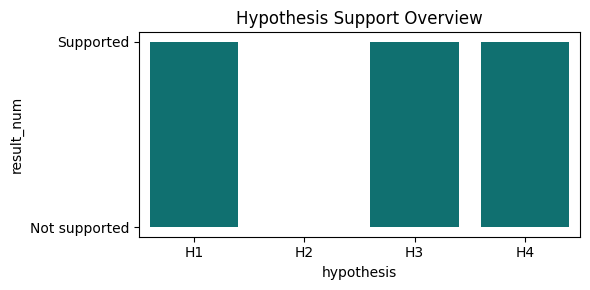

In [ ]:
def pick_result(name):
    row = results_df.loc[results_df['experiment_name'] == name]
    if row.empty:
        raise ValueError(f"Experiment not found in results_df: {name}")
    return row.iloc[0]

baseline = pick_result('baseline_relu_adam')
deeper = pick_result('deeper_relu_adam')
dropout = pick_result('relu_adam_dropout')

optimizer_subset = results_df[results_df['experiment_name'].isin([
    'baseline_relu_adam',
    'relu_rmsprop',
    'tanh_sgd',
    'relu_sgd_momentum'
])]

h1_supported = (baseline['validation_f1'] >= 0.88) and (baseline['test_f1'] >= 0.88)
h2_supported = deeper['validation_f1'] > baseline['validation_f1']
h3_supported = dropout['validation_f1'] > deeper['validation_f1']
h4_spread = optimizer_subset['validation_f1'].max() - optimizer_subset['validation_f1'].min()
h4_supported = h4_spread > 0.002

hypothesis_summary = pd.DataFrame([
    {'hypothesis': 'H1', 'condition': 'baseline validation_f1 >= 0.88 and test_f1 >= 0.88', 'result': bool(h1_supported)},
    {'hypothesis': 'H2', 'condition': 'deeper model validation_f1 > baseline validation_f1', 'result': bool(h2_supported)},
    {'hypothesis': 'H3', 'condition': 'dropout model validation_f1 > no-dropout deeper model', 'result': bool(h3_supported)},
    {'hypothesis': 'H4', 'condition': 'optimizer comparison shows non-trivial validation_f1 spread', 'result': bool(h4_supported)},
])

display(hypothesis_summary)

summary_plot = hypothesis_summary.copy()
summary_plot['result_num'] = summary_plot['result'].astype(int)